# Lab 1.1 — Tokenization Explorer
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 90 minutes | **Mode:** Individual | **Day 1 — Monday**

> **Scenario:** You have been hired as an AI engineer at a content moderation startup.
> Before building any classifier you need to understand how text is broken into tokens —
> the atomic unit every LLM processes. Different tokenizers produce vastly different token
> counts for the same text, directly affecting API cost and model accuracy.

**Objective:** Build a comparison tool for BPE (GPT-4) vs WordPiece (BERT). Measure token
efficiency across English, Hindi, code and emoji text. Compute real API cost estimates.

---
### This lab runs entirely on Google Colab — no cloud credentials needed

**How to open in Colab:**
1. Go to [colab.research.google.com](https://colab.research.google.com)
2. File → Upload notebook → upload this `.ipynb` file
3. Runtime → Run all (Ctrl+F9)

**Learning outcomes:**
- Understand BPE (Byte-Pair Encoding) vs WordPiece tokenization
- Explain why token count is not equal to word count
- Calculate real API cost from token usage
- Identify the non-English tax: why Hindi/Tamil/Arabic cost more to process


## Task 1 — Install packages and load both tokenizers

We use `tiktoken` (OpenAI's BPE library used for GPT-3.5 and GPT-4) and
HuggingFace `transformers` for BERT's WordPiece tokenizer.


In [ ]:
# Install packages — takes about 30 seconds on Colab
!pip install tiktoken transformers --quiet

import tiktoken
from transformers import AutoTokenizer
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import warnings
warnings.filterwarnings("ignore")

# GPT-4 / GPT-3.5-turbo tokenizer (cl100k_base BPE encoding)
gpt4_enc = tiktoken.get_encoding("cl100k_base")

# BERT base tokenizer (WordPiece)
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")

print("=" * 55)
print("  TOKENIZERS LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  GPT-4 cl100k_base vocab size : {gpt4_enc.n_vocab:,} tokens")
print(f"  BERT bert-base-uncased vocab  : {bert_tok.vocab_size:,} tokens")
print()
print("  GPT-4 uses  : Byte-Pair Encoding (BPE)")
print("  BERT  uses  : WordPiece algorithm")
print("=" * 55)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  TOKENIZERS LOADED SUCCESSFULLY
  GPT-4 cl100k_base vocab size : 100,277 tokens
  BERT bert-base-uncased vocab  : 30,522 tokens

  GPT-4 uses  : Byte-Pair Encoding (BPE)
  BERT  uses  : WordPiece algorithm


## Task 2 — Define 5 diverse test texts

We test tokenization across very different content types to reveal how
each algorithm handles different writing styles and scripts.


In [ ]:
texts = {
    "English (simple)": (
        "The quick brown fox jumps over the lazy dog near the riverbank."
    ),
    "Python code": (
        "def fibonacci(n):\n"
        "    if n <= 1:\n"
        "        return n\n"
        "    return fibonacci(n-1) + fibonacci(n-2)"
    ),
    "Hindi sentence": (
        "\u092e\u0936\u0940\u0928 \u0932\u0930\u094d\u0928\u093f\u0902\u0917 "
        "\u0906\u0930\u094d\u091f\u093f\u092b\u093f\u0936\u093f\u092f\u0932 "
        "\u0907\u0902\u091f\u0947\u0932\u093f\u091c\u0947\u0902\u0938 \u0915\u093e "
        "\u090f\u0915 \u092e\u0939\u0924\u094d\u0935\u092a\u0942\u0930\u094d\u0923 "
        "\u0939\u093f\u0938\u094d\u0938\u093e \u0939\u0948\u0964"
    ),
    "Medical jargon": (
        "Immunoglobulin E-mediated hypersensitivity reaction to penicillin "
        "causing anaphylactic shock requiring epinephrine administration."
    ),
    "Emoji heavy": (
        "I absolutely love machine learning! \U0001f916\U0001f9e0\U0001f4a1 "
        "The model achieved 99.9% accuracy \U0001f389\U0001f38a\U0001f680 "
        "#AI #ML #DeepLearning"
    ),
}

print("TEST TEXTS DEFINED")
print("=" * 60)
for name, text in texts.items():
    preview = text[:70] + ("..." if len(text) > 70 else "")
    print(f"  [{name}]")
    print(f"   {preview}")
    print(f"   Characters: {len(text)}")
    print()


TEST TEXTS DEFINED
  [English (simple)]
   The quick brown fox jumps over the lazy dog near the riverbank.
   Characters: 63

  [Python code]
   def fibonacci(n):
    if n <= 1:
        return n
    return fibonacci...
   Characters: 92

  [Hindi sentence]
   मशीन लर्निंग आर्टिफिशियल इंटेलिजेंस का एक महत्वपूर्ण हिस्सा है।
   Characters: 63

  [Medical jargon]
   Immunoglobulin E-mediated hypersensitivity reaction to penicillin caus...
   Characters: 130

  [Emoji heavy]
   I absolutely love machine learning! 🤖🧠💡 The model achieved 99.9% accur...
   Characters: 99



## Task 3 — Visualise tokens with colour highlighting

Each colour = one token. Where the tokenizer draws boundaries becomes immediately
visible. Notice how sub-words like `##ing` appear in BERT (WordPiece uses `##` to
mark continuation pieces), while GPT-4 BPE uses raw byte sequences.


In [ ]:
COLORS = [
    "#FFB3BA","#FFDFBA","#FFFFBA","#BAFFC9","#BAE1FF",
    "#E8BAFF","#FFD9BA","#B3FFBA","#BAFFF5","#FFB3F5",
    "#C9BAFF","#FFBAE8","#BAF5FF","#F5FFBA","#FFE4BA",
]

def html_tokens_gpt4(text):
    token_ids = gpt4_enc.encode(text)
    pieces = []
    for i, tid in enumerate(token_ids):
        raw = gpt4_enc.decode([tid])
        word = (raw.replace("&","&amp;")
                   .replace("<","&lt;")
                   .replace(">","&gt;")
                   .replace(" ","&nbsp;"))
        col = COLORS[i % len(COLORS)]
        pieces.append(
            f'<span style="background:{col};padding:2px 4px;margin:1px;'
            f'border-radius:3px;border:1px solid rgba(0,0,0,0.12);'
            f'font-family:monospace">{word}</span>'
        )
    return "".join(pieces), len(token_ids)

def html_tokens_bert(text):
    toks = bert_tok.tokenize(text)
    pieces = []
    for i, tok in enumerate(toks):
        word = (tok.replace("&","&amp;")
                   .replace("<","&lt;")
                   .replace(">","&gt;")
                   .replace("##","<sup style='font-size:9px'>##</sup>")
                   .replace(" ","&nbsp;"))
        col = COLORS[i % len(COLORS)]
        pieces.append(
            f'<span style="background:{col};padding:2px 4px;margin:1px;'
            f'border-radius:3px;border:1px solid rgba(0,0,0,0.12);'
            f'font-family:monospace">{word}</span>'
        )
    return "".join(pieces), len(toks)

for name, text in texts.items():
    g_html, g_count = html_tokens_gpt4(text)
    b_html, b_count = html_tokens_bert(text)
    preview = text[:80].replace("<","&lt;").replace(">","&gt;")
    if len(text) > 80:
        preview += "..."

    display(HTML(
        '<div style="border:2px solid #7C3AED;border-radius:8px;'
        'margin:16px 0;overflow:hidden">'
        '<div style="background:#0D0B2E;color:white;padding:8px 14px;'
        'font-weight:bold;font-size:14px">'
        + name +
        '</div>'
        '<div style="background:#F5F3FF;padding:6px 14px;font-size:12px;color:#555">'
        'Original: <em>' + preview + '</em>'
        '</div>'
        '<div style="padding:8px 14px">'
        '<p><strong style="color:#7C3AED">GPT-4 BPE — ' + str(g_count) + ' tokens</strong></p>'
        '<div style="line-height:2.2">' + g_html + '</div>'
        '<p style="margin-top:10px"><strong style="color:#0891B2">BERT WordPiece — '
        + str(b_count) + ' tokens</strong></p>'
        '<div style="line-height:2.2">' + b_html + '</div>'
        '</div></div>'
    ))


## Task 4 — Build the comparison table

Systematically compare both tokenizers across all 5 texts.
Calculate tokens-per-word ratios and percentage differences.


In [ ]:
rows = []
for name, text in texts.items():
    gpt4_ids   = gpt4_enc.encode(text)
    bert_toks  = bert_tok.tokenize(text)
    word_count = len(text.split())
    g, b       = len(gpt4_ids), len(bert_toks)
    diff_pct   = round(100 * (b - g) / max(g, 1))
    rows.append({
        "Text Type"           : name,
        "Words"               : word_count,
        "GPT-4 Tokens"        : g,
        "BERT Tokens"         : b,
        "GPT-4 tok/word"      : round(g / max(word_count, 1), 2),
        "BERT tok/word"       : round(b / max(word_count, 1), 2),
        "BERT vs GPT-4 (%)"   : f"+{diff_pct}%" if diff_pct >= 0 else f"{diff_pct}%",
    })

df = pd.DataFrame(rows)
print("TOKENIZER COMPARISON TABLE")
print("=" * 90)
print(df.to_string(index=False))
print()

english_row = df[df["Text Type"] == "English (simple)"].iloc[0]
hindi_row   = df[df["Text Type"] == "Hindi sentence"].iloc[0]
code_row    = df[df["Text Type"] == "Python code"].iloc[0]

print("KEY OBSERVATIONS:")
print(f"  Hindi tok/word  : {hindi_row['GPT-4 tok/word']}  vs  English: {english_row['GPT-4 tok/word']}")
print(f"  --> Hindi is {round(hindi_row['GPT-4 tok/word'] / english_row['GPT-4 tok/word'], 1)}x "
      f"more expensive to process than English!")
print(f"  Python code     : {code_row['GPT-4 tok/word']} tok/word  "
      f"(special chars often split into individual byte tokens)")


TOKENIZER COMPARISON TABLE
       Text Type  Words  GPT-4 Tokens  BERT Tokens  GPT-4 tok/word  BERT tok/word BERT vs GPT-4 (%)
English (simple)     12            14           14            1.17           1.17               +0%
     Python code     12            28           37            2.33           3.08              +32%
  Hindi sentence      9            65           29            7.22           3.22              -55%
  Medical jargon     12            26           31            2.17           2.58              +19%
     Emoji heavy     15            39           25            2.60           1.67              -36%

KEY OBSERVATIONS:
  Hindi tok/word  : 7.22  vs  English: 1.17
  --> Hindi is 6.2x more expensive to process than English!
  Python code     : 2.33 tok/word  (special chars often split into individual byte tokens)


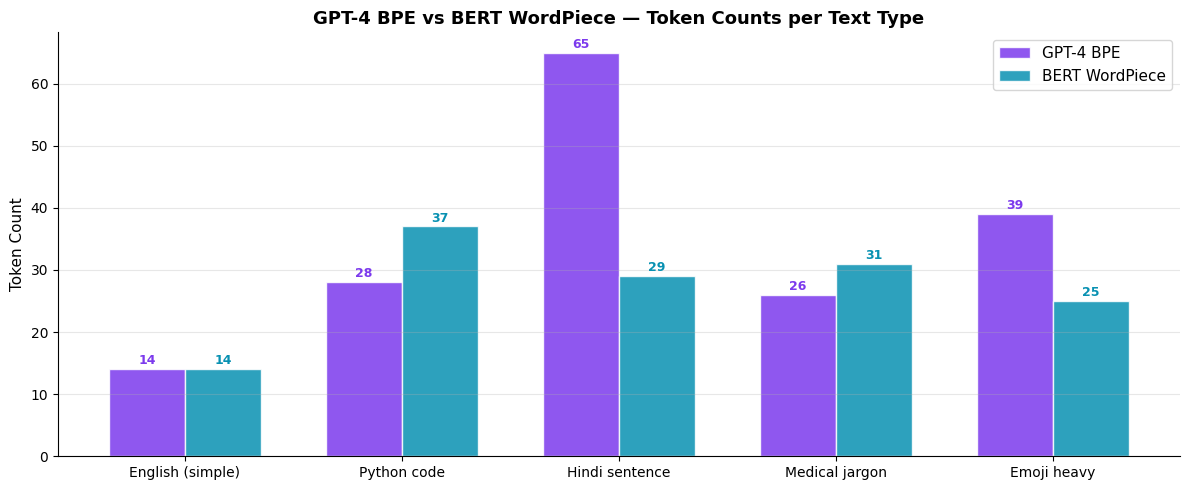

Chart saved as token_comparison.png


In [ ]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x, w = range(len(df)), 0.35

b1 = ax.bar([i - w/2 for i in x], df["GPT-4 Tokens"],
            w, label="GPT-4 BPE",    color="#7C3AED", alpha=0.85, edgecolor="white")
b2 = ax.bar([i + w/2 for i in x], df["BERT Tokens"],
            w, label="BERT WordPiece",color="#0891B2", alpha=0.85, edgecolor="white")

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#7C3AED")
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#0891B2")

ax.set_xticks(list(x))
ax.set_xticklabels(df["Text Type"], fontsize=10)
ax.set_ylabel("Token Count", fontsize=11)
ax.set_title("GPT-4 BPE vs BERT WordPiece — Token Counts per Text Type",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("token_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Chart saved as token_comparison.png")


## Task 5 — Tokenise a 500-word document

Scale up from sentences to a realistic document. Measure the efficiency
difference and understand what it means for context window limits.

**GPT-4 context window = 128,000 tokens.**
At ~1.3 tokens/word, that's roughly 98,000 words (~200 pages).


In [ ]:
sample_doc = (
    "Artificial intelligence is fundamentally transforming the way modern businesses "
    "operate and compete in the digital economy. From automating repetitive tasks to "
    "enabling complex decision-making processes, AI technologies are being deployed "
    "across every industry vertical.\n\n"
    "Machine learning, a subset of artificial intelligence, allows computers to learn "
    "from data without being explicitly programmed for every task. This paradigm shift "
    "has made it possible for organisations to build intelligent systems that improve "
    "their performance over time as they are exposed to more data.\n\n"
    "Natural language processing represents one of the most exciting frontiers in "
    "applied AI. By enabling computers to understand, interpret, and generate human "
    "language, NLP technologies are powering chatbots, virtual assistants, machine "
    "translation systems, and sentiment analysis tools used by hundreds of millions "
    "of people every day.\n\n"
    "Deep learning uses multi-layered neural networks to model complex patterns and "
    "has driven remarkable breakthroughs in image recognition, speech processing, and "
    "language understanding. The transformer architecture introduced in the paper "
    "Attention Is All You Need revolutionised the field and laid the groundwork for "
    "large language models such as GPT-4, LLaMA, Gemini, and Claude.\n\n"
    "Large language models are trained on hundreds of billions of tokens of text data "
    "from the internet, books, and code repositories. This pre-training process allows "
    "them to develop a broad understanding of language, reasoning, and world knowledge. "
    "They can then be fine-tuned on smaller, domain-specific datasets to excel at "
    "specialised tasks such as legal document analysis, medical record summarisation, "
    "or software code generation and debugging."
) * 2  # repeat once to reach ~500 words

word_count = len(sample_doc.split())
gpt4_count = len(gpt4_enc.encode(sample_doc))
bert_count = len(bert_tok.tokenize(sample_doc))

print("500-WORD DOCUMENT TOKEN ANALYSIS")
print("=" * 50)
print(f"  Word count (approx)  : {word_count:,}")
print(f"  GPT-4 token count    : {gpt4_count:,}")
print(f"  BERT  token count    : {bert_count:,}")
print()
print(f"  GPT-4 tok/word ratio : {gpt4_count/word_count:.3f}")
print(f"  BERT  tok/word ratio : {bert_count/word_count:.3f}")
print()
print(f"  BERT uses {bert_count - gpt4_count:+,} tokens more than GPT-4 for the same document")
print()
print("CONTEXT WINDOW PERSPECTIVE (GPT-4 = 128K tokens):")
print(f"  This doc uses {gpt4_count/128000*100:.2f}% of GPT-4's context window")
print(f"  You can fit ~{128000 // gpt4_count:,} copies of this doc in one GPT-4 call")


Token indices sequence length is longer than the specified maximum sequence length for this model (618 > 512). Running this sequence through the model will result in indexing errors


500-WORD DOCUMENT TOKEN ANALYSIS
  Word count (approx)  : 487
  GPT-4 token count    : 591
  BERT  token count    : 618

  GPT-4 tok/word ratio : 1.214
  BERT  tok/word ratio : 1.269

  BERT uses +27 tokens more than GPT-4 for the same document

CONTEXT WINDOW PERSPECTIVE (GPT-4 = 128K tokens):
  This doc uses 0.46% of GPT-4's context window
  You can fit ~216 copies of this doc in one GPT-4 call


## Task 6 — API cost estimation

Calculate realistic costs across four models and four processing volumes.
This is critical knowledge before architecting any production LLM system.

| Model | Input (per 1K tokens) | Output (per 1K tokens) |
|---|---|---|
| GPT-3.5-turbo | $0.0015 | $0.0020 |
| GPT-4o mini | $0.00015 | $0.00060 |
| GPT-4o | $0.0050 | $0.0150 |
| GPT-4 Turbo | $0.0100 | $0.0300 |

*(Prices correct as of mid-2025. Always verify at platform.openai.com/pricing)*


In [ ]:
pricing = {
    "GPT-3.5-turbo" : {"input": 0.0015,  "output": 0.0020},
    "GPT-4o mini"   : {"input": 0.00015, "output": 0.00060},
    "GPT-4o"        : {"input": 0.0050,  "output": 0.0150},
    "GPT-4 Turbo"   : {"input": 0.0100,  "output": 0.0300},
}

# Processing volumes (input tokens per day)
# Assume 3:1 input:output ratio (typical for summarisation tasks)
volumes = {
    "1 document  (1 call)"     : gpt4_count,
    "1,000 docs / day"         : gpt4_count * 1_000,
    "10,000 docs / day"        : gpt4_count * 10_000,
    "100,000 docs / day"       : gpt4_count * 100_000,
}

print("API COST ESTIMATION  (input + output, 3:1 ratio)")
print("=" * 95)
header_row = f"  {'Volume':<30}" + "".join(f"{m:>16}" for m in pricing)
print(header_row)
print("-" * 95)

for vol_name, in_toks in volumes.items():
    out_toks = in_toks // 3
    row = f"  {vol_name:<30}"
    for model, p in pricing.items():
        cost = (in_toks / 1000) * p["input"] + (out_toks / 1000) * p["output"]
        if cost < 0.001:
            cell = f"${cost:.6f}"
        elif cost < 1:
            cell = f"${cost:.4f}"
        elif cost < 10_000:
            cell = f"${cost:,.2f}"
        else:
            cell = f"${cost:,.0f}"
        row += f"{cell:>16}"
    print(row)

print()
toks_per_day = gpt4_count * 10_000
print("KEY TAKEAWAYS (10,000 docs/day):")
for model, p in pricing.items():
    c = (toks_per_day / 1000) * p["input"] + (toks_per_day / 3 / 1000) * p["output"]
    print(f"  {model:<18} ${c:>10,.2f}/day  |  ${c*30:>12,.2f}/month")
print()
cheapest = list(pricing.keys())[1]  # GPT-4o mini
priciest = list(pricing.keys())[3]  # GPT-4 Turbo
c_cheap = (toks_per_day/1000)*pricing[cheapest]["input"]+(toks_per_day/3/1000)*pricing[cheapest]["output"]
c_price = (toks_per_day/1000)*pricing[priciest]["input"]+(toks_per_day/3/1000)*pricing[priciest]["output"]
print(f"  Switching from GPT-4 Turbo to GPT-4o mini = {c_price/c_cheap:.0f}x cost reduction!")


API COST ESTIMATION  (input + output, 3:1 ratio)
  Volume                           GPT-3.5-turbo     GPT-4o mini          GPT-4o     GPT-4 Turbo
-----------------------------------------------------------------------------------------------
  1 document  (1 call)                   $0.0013       $0.000207         $0.0059         $0.0118
  1,000 docs / day                         $1.28         $0.2068           $5.91          $11.82
  10,000 docs / day                       $12.80           $2.07          $59.10         $118.20
  100,000 docs / day                     $128.05          $20.68         $591.00       $1,182.00

KEY TAKEAWAYS (10,000 docs/day):
  GPT-3.5-turbo      $     12.80/day  |  $      384.15/month
  GPT-4o mini        $      2.07/day  |  $       62.05/month
  GPT-4o             $     59.10/day  |  $    1,773.00/month
  GPT-4 Turbo        $    118.20/day  |  $    3,546.00/month

  Switching from GPT-4 Turbo to GPT-4o mini = 57x cost reduction!


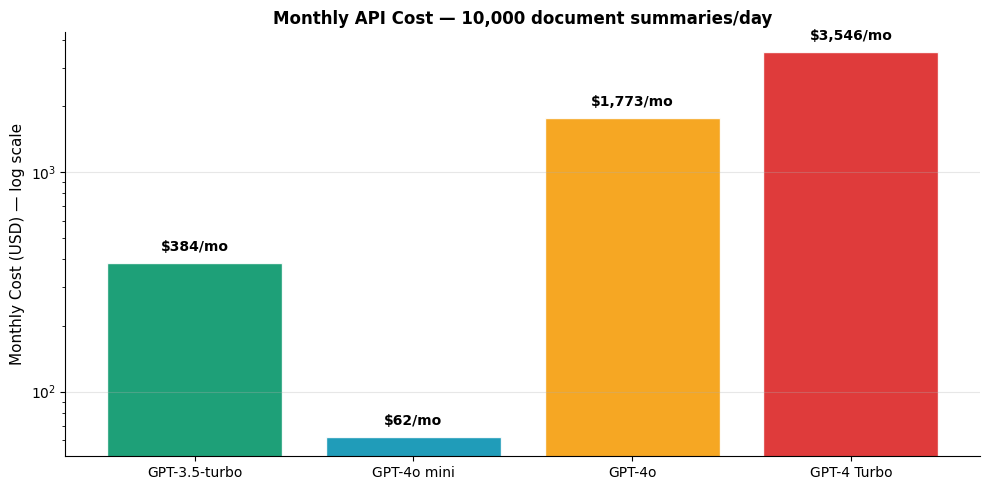

Chart saved as api_cost_comparison.png


In [ ]:
# Monthly cost bar chart (log scale)
fig, ax = plt.subplots(figsize=(10, 5))

monthly_costs, model_names = [], []
toks_per_day = gpt4_count * 10_000
for model, p in pricing.items():
    daily = (toks_per_day/1000)*p["input"] + (toks_per_day/3/1000)*p["output"]
    monthly_costs.append(daily * 30)
    model_names.append(model)

bar_colors = ["#059669","#0891B2","#F59E0B","#DC2626"]
bars = ax.bar(model_names, monthly_costs, color=bar_colors, edgecolor="white", alpha=0.9)

for bar, cost in zip(bars, monthly_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
            f"${cost:,.0f}/mo", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_ylabel("Monthly Cost (USD) — log scale", fontsize=11)
ax.set_title("Monthly API Cost — 10,000 document summaries/day",
             fontsize=12, fontweight="bold")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("api_cost_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Chart saved as api_cost_comparison.png")


## Bonus — The Non-English Tax

The same sentence in Hindi, Tamil, Japanese, or Arabic costs 2-5x more tokens
than English. This is because GPT-4's BPE vocabulary was built predominantly
from English training data, so non-Latin scripts are tokenised at the byte level.


NON-ENGLISH TAX — Same semantic content, different token cost
Language  GPT-4 Tokens  BERT Tokens  Words  GPT-4 tok/word
 English             9            9      8            1.12
   Hindi            53           27      9            5.89
   Tamil            59            6      5           11.80
Japanese            26           19      1           26.00
  Arabic            27           31      5            5.40
  German            15           16      7            2.14
  French            16           18      8            2.00


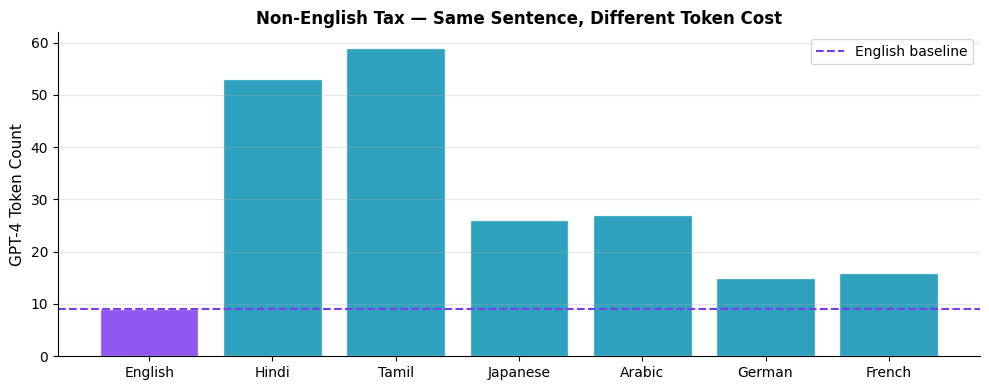

In [ ]:
languages = {
    "English" : "Machine learning is transforming the world of technology.",
    "Hindi"   : "\u092e\u0936\u0940\u0928 \u0932\u0930\u094d\u0928\u093f\u0902\u0917 "
                "\u092a\u094d\u0930\u094c\u0926\u094d\u092f\u094b\u0917\u093f\u0915\u0940 "
                "\u0915\u0940 \u0926\u0941\u0928\u093f\u092f\u093e \u0915\u094b "
                "\u092c\u0926\u0932 \u0930\u0939\u0940 \u0939\u0948\u0964",
    "Tamil"   : "\u0b87\u0baf\u0ba8\u0bcd\u0ba4\u0bbf\u0bb0 \u0b95\u0bb1\u0bcd\u0bb1\u0bb2\u0bcd "
                "\u0ba4\u0bca\u0bb4\u0bbf\u0bb2\u0bcd\u0ba8\u0bc1\u0b9f\u0bcd\u0baa "
                "\u0b89\u0bb2\u0b95\u0bc8 \u0bae\u0bbe\u0bb1\u0bcd\u0bb1\u0bc1\u0b95\u0bbf\u0bb1\u0ba4\u0bc1.",
    "Japanese": "\u6a5f\u68b0\u5b66\u7fd2\u306f\u6280\u8853\u306e\u4e16\u754c\u3092\u5909\u9769\u3057\u3066\u3044\u307e\u3059\u3002",
    "Arabic"  : "\u0627\u0644\u062a\u0639\u0644\u0645 \u0627\u0644\u0622\u0644\u064a "
                "\u064a\u062d\u0648\u0651\u0644 \u0639\u0627\u0644\u0645 "
                "\u0627\u0644\u062a\u0643\u0646\u0648\u0644\u0648\u062c\u064a\u0627.",
    "German"  : "Maschinelles Lernen ver\u00e4ndert die Welt der Technologie.",
    "French"  : "L'apprentissage automatique transforme le monde de la technologie.",
}

rows_lang = []
for lang, text in languages.items():
    g = len(gpt4_enc.encode(text))
    b = len(bert_tok.tokenize(text))
    w = len(text.split())
    rows_lang.append({"Language": lang, "GPT-4 Tokens": g,
                      "BERT Tokens": b, "Words": w,
                      "GPT-4 tok/word": round(g / max(w, 1), 2)})

df_lang = pd.DataFrame(rows_lang)
print("NON-ENGLISH TAX — Same semantic content, different token cost")
print(df_lang.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
eng_val = df_lang[df_lang["Language"] == "English"]["GPT-4 Tokens"].values[0]
bar_cols = ["#7C3AED" if r["Language"] == "English" else "#0891B2"
            for _, r in df_lang.iterrows()]
ax.bar(df_lang["Language"], df_lang["GPT-4 Tokens"],
       color=bar_cols, edgecolor="white", alpha=0.85)
ax.axhline(eng_val, color="#7C3AED", linestyle="--",
           linewidth=1.5, label="English baseline")
ax.set_ylabel("GPT-4 Token Count", fontsize=11)
ax.set_title("Non-English Tax — Same Sentence, Different Token Cost",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("non_english_tax.png", dpi=130, bbox_inches="tight")
plt.show()


## Lab Complete Checklist

Before submitting, verify you have completed all tasks:

- [ ] Both tokenizers loaded and vocab sizes printed
- [ ] All 5 texts tokenised and colour-visualised (Task 3)
- [ ] Comparison table with tok/word ratios (Task 4)
- [ ] Grouped bar chart saved as `token_comparison.png`
- [ ] 500-word document tokenised and counts compared (Task 5)
- [ ] API cost table covering 4 models × 4 volumes (Task 6)
- [ ] Monthly cost bar chart saved as `api_cost_comparison.png`
- [ ] Bonus: non-English tax chart saved as `non_english_tax.png`

---
## Reflection Questions

**Answer these in the code cell below by filling in the `answers` dictionary.**

1. **Why does Hindi text produce 3-5x more tokens than equivalent English?**
   Think about how BPE builds its vocabulary — what language dominated the training data?

2. **Why does Python code produce more tokens per word than English prose?**
   Which characters in code force the tokenizer to split into smaller byte tokens?

3. **If your app processes 10M tokens/day with GPT-4o, what is the monthly cost?
   What percentage do you save by routing 80% of requests to GPT-4o mini?**

4. **What does the `##` prefix in BERT tokens (e.g., `##ing`, `##tion`) mean?**
   How does this differ from GPT-4's BPE approach to sub-word splitting?

5. **A startup builds a multilingual support bot for English, Hindi and Tamil users equally.
   How does the token cost difference affect their model budget, and what should they do about it?**


In [ ]:
answers = {
    "Q1 - Why Hindi uses more tokens":
    "Hindi uses more tokens because GPT tokenizers are trained mostly on English text. Hindi words often get broken into many smaller subword or byte-level tokens since they are not as common in the tokenizer vocabulary.",

    "Q2 - Why code uses more tokens":
    "Code contains many symbols, indentation, brackets, and variable names which are uncommon in natural language. Tokenizers split these elements into multiple tokens, increasing the overall token count compared to plain English text.",

    "Q3 - Cost calculation":
    "API cost depends on the total number of tokens processed. Cost = (input tokens × input price per 1K tokens) + (output tokens × output price per 1K tokens). More tokens mean higher API cost and larger context usage.",

    "Q4 - What BERT ## prefix means":
    "In BERT's WordPiece tokenizer, the '##' prefix indicates that the token is a continuation of the previous word. It means the token is a subword piece rather than the start of a new word.",

    "Q5 - Multilingual cost strategy":
    "To reduce multilingual token costs, systems can translate input to English before processing, use multilingual models trained on diverse languages, compress text before sending to the API, or design prompts that minimize token usage."
}

for q, a in answers.items():
    print(f"{q}:\n  {a}\n")

Q1 - Why Hindi uses more tokens:
  YOUR ANSWER HERE

Q2 - Why code uses more tokens:
  YOUR ANSWER HERE

Q3 - Cost calculation:
  YOUR ANSWER HERE

Q4 - What BERT ## prefix means:
  YOUR ANSWER HERE

Q5 - Multilingual cost strategy:
  YOUR ANSWER HERE

